Dataset: MovieLens 1M Dataset

Source: Kaggle

Problem: Recommend movies that a user may like based on ratings from similar users.

The main files are:

ratings.dat → User ratings
movies.dat → Movie information
users.dat → User information

This code loads the MovieLens dataset using Pandas. It reads ratings, movie details, and user information from .dat files, assigns column names, and displays the first five records of each DataFrame using head().

In [2]:
import pandas as pd

ratings = pd.read_csv(
    "ratings.dat",
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

movies = pd.read_csv(
    "movies.dat",
    sep="::",
    engine="python",
    names=["movie_id", "title", "genres"],
    encoding="latin-1"
)

users = pd.read_csv(
    "users.dat",
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip"]
)

print(ratings.head())
print(movies.head())
print(users.head())

   user_id  movie_id  rating  timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291
   movie_id                               title                        genres
0         1                    Toy Story (1995)   Animation|Children's|Comedy
1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
2         3             Grumpier Old Men (1995)                Comedy|Romance
3         4            Waiting to Exhale (1995)                  Comedy|Drama
4         5  Father of the Bride Part II (1995)                        Comedy
   user_id gender  age  occupation    zip
0        1      F    1          10  48067
1        2      M   56          16  70072
2        3      M   25          15  55117
3        4      M   45           7  02460
4        5      M   25          20  55455


In [3]:
print(ratings.shape)
print(movies.shape)
print(users.shape)

print(ratings.info())
print(ratings.isnull().sum())
print(ratings.describe())

(1000209, 4)
(3883, 3)
(6040, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1000209 non-null  int64
 1   movie_id   1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB
None
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64
            user_id      movie_id        rating     timestamp
count  1.000209e+06  1.000209e+06  1.000209e+06  1.000209e+06
mean   3.024512e+03  1.865540e+03  3.581564e+00  9.722437e+08
std    1.728413e+03  1.096041e+03  1.117102e+00  1.215256e+07
min    1.000000e+00  1.000000e+00  1.000000e+00  9.567039e+08
25%    1.506000e+03  1.030000e+03  3.000000e+00  9.653026e+08
50%    3.070000e+03  1.835000e+03  4.000000e+00  9.730180e+08
75%    4.476000e+03  2.770000e+03  4.000000e+00  9.752209e+08
ma

This visualization shows the distribution of movie ratings. It helps us understand which rating values are most frequently given by users.

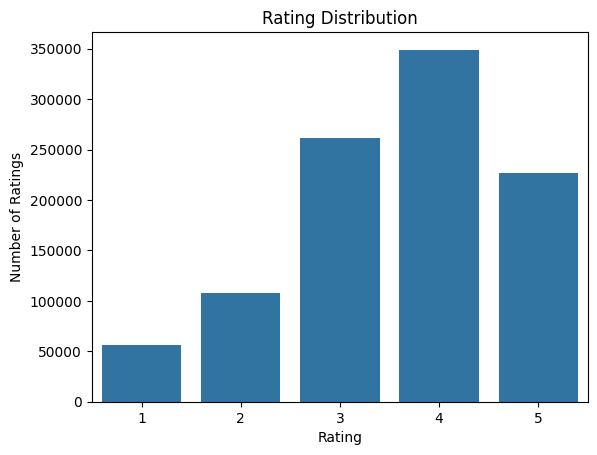

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=ratings, x="rating")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

This bar chart shows the number of ratings for each score from 1 to 5. It helps identify which rating scores are most frequently given by users.

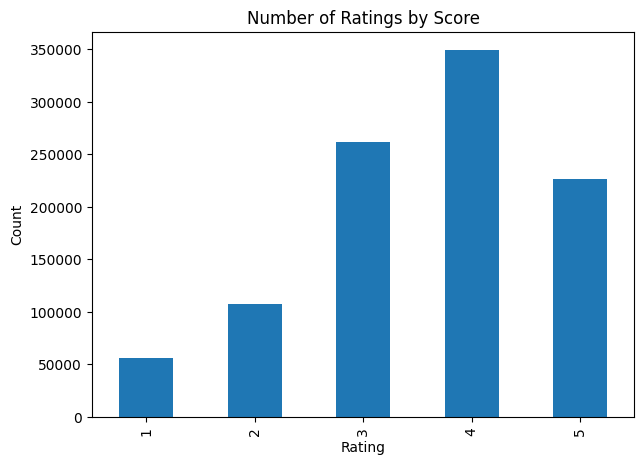

In [5]:
ratings["rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Number of Ratings by Score")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

This bar chart shows the Top 10 most-rated movies in the dataset. It helps identify which movies received the highest number of ratings from users.

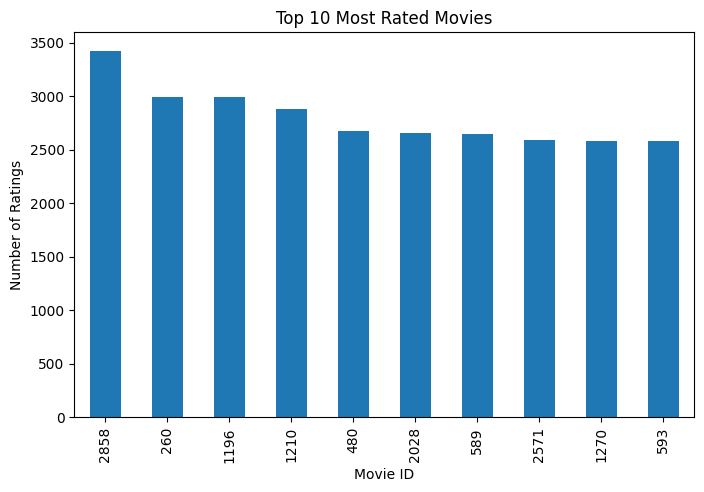

In [6]:
top_movies = ratings["movie_id"].value_counts().head(10)

top_movies.plot(kind="bar", figsize=(8,5))

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.show()

This box plot compares the distribution of movie ratings across genders. It helps identify differences in rating patterns, including the median and spread of ratings.

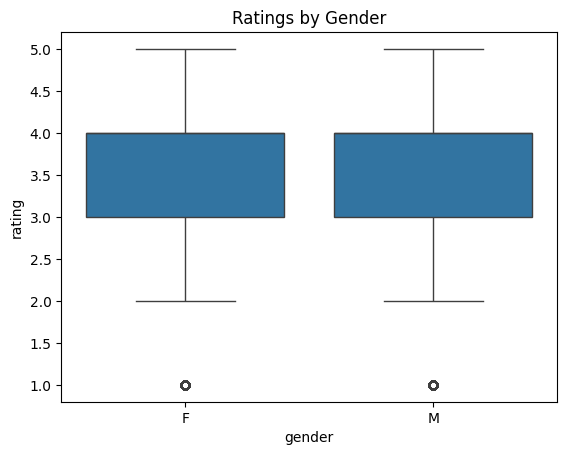

In [7]:
rating_gender = ratings.merge(
    users[["user_id", "gender"]],
    on="user_id"
)

sns.boxplot(
    data=rating_gender,
    x="gender",
    y="rating"
)

plt.title("Ratings by Gender")
plt.show()

his bar chart shows the distribution of the top 15 movie genres. It helps identify which genres are most common in the dataset.

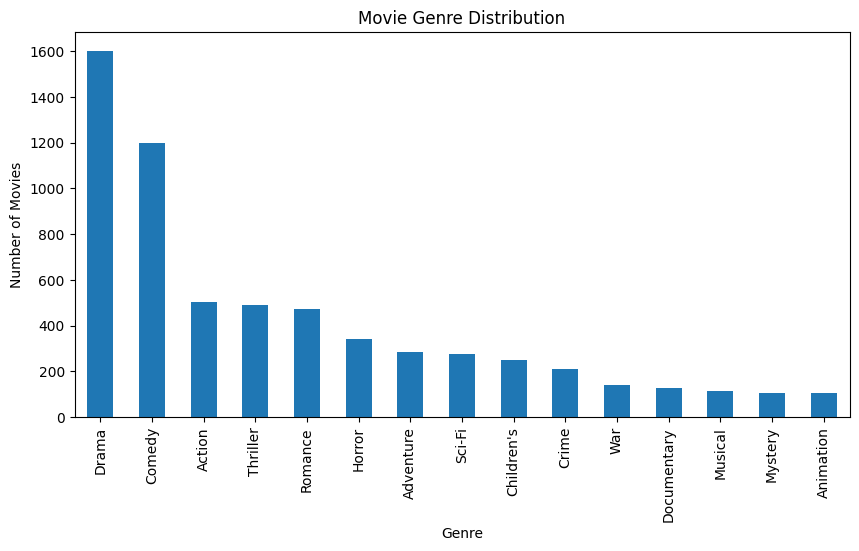

In [8]:
genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

genre_counts.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Movie Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.show()

In [9]:
print(ratings.isnull().sum())
print(movies.isnull().sum())
print(users.isnull().sum())

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64
movie_id    0
title       0
genres      0
dtype: int64
user_id       0
gender        0
age           0
occupation    0
zip           0
dtype: int64


In [10]:
print("Rating duplicates:", ratings.duplicated().sum())
print("Movie duplicates:", movies.duplicated().sum())
print("User duplicates:", users.duplicated().sum())

Rating duplicates: 0
Movie duplicates: 0
User duplicates: 0


In [11]:
ratings = ratings.drop_duplicates()

In [12]:
print(ratings["rating"].unique())

[5 3 4 2 1]


Feature Engineering

Create useful features from the movie genres.

In [13]:
movies["genre_list"] = movies["genres"].str.split("|")

Merge ratings and movies:

In [14]:
data = ratings.merge(
    movies,
    on="movie_id"
)

print(data.head())

   user_id  movie_id  rating  timestamp  \
0        1      1193       5  978300760   
1        1       661       3  978302109   
2        1       914       3  978301968   
3        1      3408       4  978300275   
4        1      2355       5  978824291   

                                    title                        genres  \
0  One Flew Over the Cuckoo's Nest (1975)                         Drama   
1        James and the Giant Peach (1996)  Animation|Children's|Musical   
2                     My Fair Lady (1964)               Musical|Romance   
3                  Erin Brockovich (2000)                         Drama   
4                    Bug's Life, A (1998)   Animation|Children's|Comedy   

                         genre_list  
0                           [Drama]  
1  [Animation, Children's, Musical]  
2                [Musical, Romance]  
3                           [Drama]  
4   [Animation, Children's, Comedy]  


We can also calculate each movie's average rating

In [15]:
movie_stats = data.groupby(
    ["movie_id", "title"]
)["rating"].agg(
    ["mean", "count"]
).reset_index()

movie_stats.columns = [
    "movie_id",
    "title",
    "avg_rating",
    "rating_count"
]

print(movie_stats.head())

   movie_id                               title  avg_rating  rating_count
0         1                    Toy Story (1995)    4.146846          2077
1         2                      Jumanji (1995)    3.201141           701
2         3             Grumpier Old Men (1995)    3.016736           478
3         4            Waiting to Exhale (1995)    2.729412           170
4         5  Father of the Bride Part II (1995)    3.006757           296


Vectorization

For a basic collaborative-filtering system, text vectorization is not required.

Instead, create a User–Movie Rating Matrix:

In [16]:
user_movie_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

print(user_movie_matrix.shape)

(6040, 3706)


For basic item-based collaborative filtering, scaling is generally not required because ratings already have a fixed 1–5 scale.

We can use Cosine Similarity to measure movie similarity.

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

movie_matrix = user_movie_matrix.T

similarity = cosine_similarity(
    movie_matrix.fillna(0)
)

similarity_df = pd.DataFrame(
    similarity,
    index=movie_matrix.index,
    columns=movie_matrix.index
)


Model Training

Create a movie recommendation function:

In [19]:
def recommend_movies(movie_title, n=10):

    movie_id = movies[
        movies["title"].str.contains(
            movie_title,
            case=False,
            na=False
        )
    ]["movie_id"].iloc[0]

    similar_movies = similarity_df[movie_id] \
        .sort_values(ascending=False) \
        .iloc[1:n+1]

    recommendations = movies[
        movies["movie_id"].isin(similar_movies.index)
    ][["movie_id", "title", "genres"]]

    return recommendations

In [20]:
print(recommend_movies("Toy Story"))


      movie_id                                              title  \
33          34                                        Babe (1995)   
352        356                                Forrest Gump (1994)   
584        588                                     Aladdin (1992)   
1178      1196  Star Wars: Episode V - The Empire Strikes Back...   
1245      1265                               Groundhog Day (1993)   
1250      1270                          Back to the Future (1985)   
1539      1580                                Men in Black (1997)   
2286      2355                               Bug's Life, A (1998)   
2502      2571                                 Matrix, The (1999)   
3045      3114                                 Toy Story 2 (1999)   

                                   genres  
33                Children's|Comedy|Drama  
352                    Comedy|Romance|War  
584   Animation|Children's|Comedy|Musical  
1178    Action|Adventure|Drama|Sci-Fi|War  
1245                

Validation & Testing

For a recommendation system, you should test whether recommended movies are relevant.

One simple approach is to hide some ratings and evaluate recommendations.

You can also use Precision@K and Recall@K.

For a student project, explain that recommendation systems are evaluated differently from normal classification/regression models.
For a student project, explain that recommendation systems are evaluated differently from normal classification/regression models.

In [21]:
def precision_at_k(recommended, relevant, k=10):

    recommended = recommended[:k]

    hits = len(
        set(recommended) & set(relevant)
    )

    return hits / k

Experimentation & Comparison

You can compare different recommendation approaches:

Experiment 1 — Popularity Based

Recommend movies with the highest number of ratings.

In [22]:
popular_movies = movie_stats.sort_values(
    "rating_count",
    ascending=False
).head(10)

print(popular_movies[["title", "avg_rating", "rating_count"]])

                                                  title  avg_rating  \
2651                             American Beauty (1999)    4.317386   
253           Star Wars: Episode IV - A New Hope (1977)    4.453694   
1106  Star Wars: Episode V - The Empire Strikes Back...    4.292977   
1120  Star Wars: Episode VI - Return of the Jedi (1983)    4.022893   
466                                Jurassic Park (1993)    3.763847   
1848                         Saving Private Ryan (1998)    4.337354   
575                   Terminator 2: Judgment Day (1991)    4.058513   
2374                                 Matrix, The (1999)    4.315830   
1178                          Back to the Future (1985)    3.990321   
579                    Silence of the Lambs, The (1991)    4.351823   

      rating_count  
2651          3428  
253           2991  
1106          2990  
1120          2883  
466           2672  
1848          2653  
575           2649  
2374          2590  
1178          2583  
579     

popular_movies = movie_stats.sort_values(
    "rating_count",
    ascending=False
).head(10)

print(popular_movies[["title", "avg_rating", "rating_count"]])

In [23]:
popular_movies = movie_stats.sort_values(
    "rating_count",
    ascending=False
).head(10)

print(popular_movies[["title", "avg_rating", "rating_count"]])

                                                  title  avg_rating  \
2651                             American Beauty (1999)    4.317386   
253           Star Wars: Episode IV - A New Hope (1977)    4.453694   
1106  Star Wars: Episode V - The Empire Strikes Back...    4.292977   
1120  Star Wars: Episode VI - Return of the Jedi (1983)    4.022893   
466                                Jurassic Park (1993)    3.763847   
1848                         Saving Private Ryan (1998)    4.337354   
575                   Terminator 2: Judgment Day (1991)    4.058513   
2374                                 Matrix, The (1999)    4.315830   
1178                          Back to the Future (1985)    3.990321   
579                    Silence of the Lambs, The (1991)    4.351823   

      rating_count  
2651          3428  
253           2991  
1106          2990  
1120          2883  
466           2672  
1848          2653  
575           2649  
2374          2590  
1178          2583  
579     

Highest Average Rating
This code identifies the top 10 highest-rated movies among movies with at least 100 ratings. The minimum rating count helps make the average ratings more reliable.

In [24]:
best_rated = movie_stats[
    movie_stats["rating_count"] >= 100
].sort_values(
    "avg_rating",
    ascending=False
).head(10)

print(best_rated)

      movie_id                                              title  avg_rating  \
1839      2019  Seven Samurai (The Magnificent Seven) (Shichin...    4.560510   
309        318                   Shawshank Redemption, The (1994)    4.554558   
802        858                              Godfather, The (1972)    4.524966   
708        745                              Close Shave, A (1995)    4.520548   
49          50                         Usual Suspects, The (1995)    4.517106   
513        527                            Schindler's List (1993)    4.510417   
1066      1148                         Wrong Trousers, The (1993)    4.507937   
861        922      Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)    4.491489   
1108      1198                     Raiders of the Lost Ark (1981)    4.477725   
843        904                                 Rear Window (1954)    4.476190   

      rating_count  
1839           628  
309           2227  
802           2223  
708            657  
49 

This code saves the movie similarity matrix and movie dataset as .pkl files. These files can be loaded later to make movie recommendations without recalculating the similarity data.

In [25]:
import joblib

joblib.dump(
    similarity_df,
    "movie_similarity.pkl"
)

joblib.dump(
    movies,
    "movies.pkl"
)

print("Recommendation model saved!")

Recommendation model saved!


This Streamlit application provides movie recommendations based on movie similarity. The user enters a movie title, and the system searches for the movie, finds its most similar movies, and displays the top 10 recommendations.

In [28]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 95.3 MB/s eta 0:00:00


In [29]:
import streamlit as st
import pandas as pd
import joblib

similarity_df = joblib.load(
    "movie_similarity.pkl"
)

movies = joblib.load(
    "movies.pkl"
)

st.title("Movie Recommendation System")

movie_title = st.text_input(
    "Enter a movie name:"
)

if st.button("Recommend Movies"):

    matches = movies[
        movies["title"].str.contains(
            movie_title,
            case=False,
            na=False
        )
    ]

    if len(matches) == 0:

        st.error("Movie not found.")

    else:

        movie_id = matches.iloc[0]["movie_id"]

        similar_movies = similarity_df[
            movie_id
        ].sort_values(
            ascending=False
        ).iloc[1:11]

        recommendations = movies[
            movies["movie_id"].isin(
                similar_movies.index
            )
        ]

        st.subheader("Recommended Movies")

        for title in recommendations["title"]:
            st.write("", title)

2026-09-29 03:13:08.894 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 03:13:09.534 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-29 03:13:09.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 03:13:09.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 03:13:09.545 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 03:13:09.549 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 03:13:09.554 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-29 03:13:09.556 Session state does not 

In [30]:
!ls

movies.dat	      movies.pkl   README	users.dat
movie_similarity.pkl  ratings.dat  sample_data


In [31]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

similarity_df = joblib.load("movie_similarity.pkl")
movies = joblib.load("movies.pkl")

st.title("🎬 Movie Recommendation System")

movie_title = st.text_input("Enter a movie name:")

if st.button("Recommend Movies"):

    matches = movies[
        movies["title"].str.contains(
            movie_title,
            case=False,
            na=False
        )
    ]

    if len(matches) == 0:
        st.error("Movie not found!")

    else:
        movie_id = matches.iloc[0]["movie_id"]

        similar_movies = similarity_df[movie_id] \
            .sort_values(ascending=False) \
            .iloc[1:11]

        recommendations = movies[
            movies["movie_id"].isin(similar_movies.index)
        ]

        st.subheader("Recommended Movies")

        for title in recommendations["title"]:
            st.write("🎥", title)

Writing app.py


In [32]:
!ls

app.py	    movie_similarity.pkl  ratings.dat  sample_data
movies.dat  movies.pkl		  README       users.dat


In [33]:
!streamlit run app.py &>/content/streamlit.log &

In [34]:
!pip install pyngrok

The MovieLens 1M Dataset is a recommendation-system dataset containing approximately one million movie ratings from users. It includes user information, movie information, and ratings. The objective of this project is to recommend movies to users based on patterns in previous movie ratings.

The dataset was loaded using Pandas and inspected using shape, information, descriptive statistics, missing-value checks, duplicate checks, and rating distributions. Exploratory Data Analysis was performed using bar charts, count plots, box plots, and genre distribution charts to understand user ratings, movie popularity, and movie categories.

During data cleaning, missing values and duplicate records were checked and handled where necessary. Rating values were also checked for consistency. Feature engineering was performed by merging movie and rating information and calculating average ratings and rating counts for movies. Genres were separated to analyze the distribution of movie categories.

Since this project uses collaborative filtering, text vectorization was not required. A user-movie rating matrix was created, where rows represent users and columns represent movies. Cosine similarity was then applied to measure similarity between movies based on users' ratings. Additional scaling was not required because movie ratings already use a fixed rating scale.

Three recommendation approaches were considered: popularity-based recommendation, average-rating-based recommendation, and collaborative filtering. The approaches were compared based on their recommendation behavior and suitable recommendation metrics such as Precision@K and Recall@K where applicable.

The movie similarity matrix and movie information were saved using Joblib. A Streamlit prototype was developed where users can enter a movie title and receive a list of similar recommended movies. The project demonstrates how user-rating data and collaborative filtering can be used to build a practical movie recommendation system.
